In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

# Load credentials
load_dotenv('../.env')

def get_connection():
    connection_string = (
        f"DRIVER={{ODBC Driver 17 for SQL Server}};"
        f"SERVER={os.getenv('DB_SERVER')},1433;"
        f"DATABASE={os.getenv('DB_NAME')};"
        f"UID={os.getenv('DB_USERNAME')};"
        f"PWD={os.getenv('DB_PASSWORD')};"
        f"Encrypt=yes;"
        f"TrustServerCertificate=no;"
        f"Connection Timeout=30;"
    )
    return pyodbc.connect(connection_string)

# Test connection
conn = get_connection()
print("✅ Connected to Azure SQL!")

✅ Connected to Azure SQL!


In [5]:
# Load all tables using pyodbc directly
conn = get_connection()

teams_df = pd.read_sql("SELECT * FROM teams", conn)
matches_df = pd.read_sql("SELECT * FROM matches", conn)

matches_full_df = pd.read_sql("""
    SELECT 
        m.match_id,
        m.match_date,
        m.stage,
        m.group_name,
        t1.team_name as home_team,
        t1.fifa_code as home_code,
        m.home_score,
        m.away_score,
        t2.team_name as away_team,
        t2.fifa_code as away_code,
        m.venue,
        m.city,
        CASE 
            WHEN m.home_score > m.away_score THEN t1.team_name
            WHEN m.away_score > m.home_score THEN t2.team_name
            ELSE 'Draw'
        END as result,
        m.home_score + m.away_score as total_goals
    FROM matches m
    JOIN teams t1 ON m.home_team_id = t1.team_id
    JOIN teams t2 ON m.away_team_id = t2.team_id
    WHERE m.home_score IS NOT NULL
""", conn)

print(f"✅ Teams loaded: {len(teams_df)}")
print(f"✅ Total matches loaded: {len(matches_df)}")
print(f"✅ Completed matches: {len(matches_full_df)}")
matches_full_df.head()

✅ Teams loaded: 48
✅ Total matches loaded: 72
✅ Completed matches: 16


,match_id,match_date,stage,group_name,home_team,home_code,home_score,away_score,away_team,away_code,venue,city,result,total_goals
0,2,2026-06-11 19:00:00,GROUP_STAGE,GROUP_A,Mexico,MEX,2,0,South Africa,RSA,,World,Mexico,2
1,3,2026-06-12 02:00:00,GROUP_STAGE,GROUP_A,South Korea,KOR,2,1,Czechia,CZE,,World,South Korea,3
2,4,2026-06-12 19:00:00,GROUP_STAGE,GROUP_B,Canada,CAN,1,1,Bosnia-Herzegovina,BIH,,World,Draw,2
3,5,2026-06-13 01:00:00,GROUP_STAGE,GROUP_D,United States,USA,4,1,Paraguay,PAR,,World,United States,5
4,6,2026-06-13 19:00:00,GROUP_STAGE,GROUP_B,Qatar,QAT,1,1,Switzerland,SUI,,World,Draw,2


In [6]:
# ============================================
# TOURNAMENT OVERVIEW STATS
# ============================================

total_goals = matches_full_df['total_goals'].sum()
avg_goals = matches_full_df['total_goals'].mean()
draws = len(matches_full_df[matches_full_df['result'] == 'Draw'])
home_wins = len(matches_full_df[matches_full_df['result'] == matches_full_df['home_team']])
away_wins = len(matches_full_df[matches_full_df['result'] == matches_full_df['away_team']])
highest_scoring = matches_full_df.loc[matches_full_df['total_goals'].idxmax()]

print("=" * 50)
print("⚽ FIFA WORLD CUP 2026 — TOURNAMENT STATS")
print("=" * 50)
print(f"Matches Played:        {len(matches_full_df)}")
print(f"Total Goals Scored:    {total_goals}")
print(f"Average Goals/Match:   {avg_goals:.2f}")
print(f"Home Wins:             {home_wins}")
print(f"Away Wins:             {away_wins}")
print(f"Draws:                 {draws}")
print(f"\n🏆 Highest Scoring Match:")
print(f"   {highest_scoring['home_team']} {int(highest_scoring['home_score'])} - {int(highest_scoring['away_score'])} {highest_scoring['away_team']} ({int(highest_scoring['total_goals'])} goals)")

⚽ FIFA WORLD CUP 2026 — TOURNAMENT STATS
Matches Played:        16
Total Goals Scored:    46
Average Goals/Match:   2.88
Home Wins:             7
Away Wins:             1
Draws:                 8

🏆 Highest Scoring Match:
   Germany 7 - 1 Curaçao (8 goals)


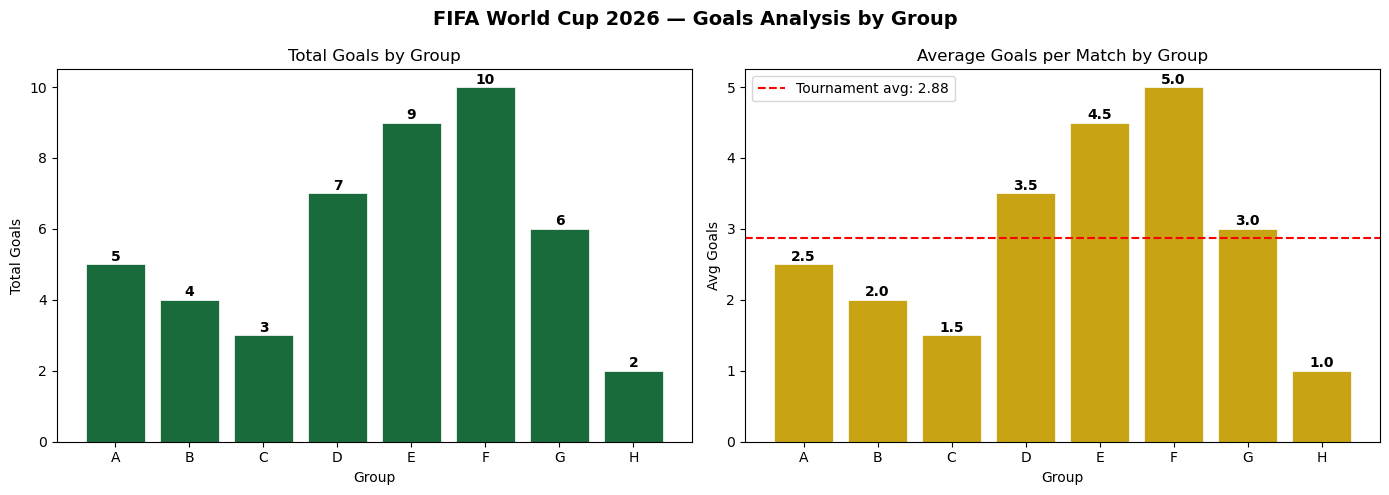

✅ Chart saved!


In [7]:
# ============================================
# GOALS BY GROUP
# ============================================

goals_by_group = matches_full_df.groupby('group_name')['total_goals'].agg(['sum', 'mean', 'count']).reset_index()
goals_by_group.columns = ['Group', 'Total Goals', 'Avg Goals', 'Matches Played']
goals_by_group['Group'] = goals_by_group['Group'].str.replace('GROUP_', '')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FIFA World Cup 2026 — Goals Analysis by Group', fontsize=14, fontweight='bold')

# Total goals bar chart
bars = axes[0].bar(goals_by_group['Group'], goals_by_group['Total Goals'], 
                    color='#1a6b3c', edgecolor='white', linewidth=0.5)
axes[0].set_title('Total Goals by Group')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Total Goals')
for bar, val in zip(bars, goals_by_group['Total Goals']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                str(int(val)), ha='center', fontweight='bold')

# Avg goals bar chart
bars2 = axes[1].bar(goals_by_group['Group'], goals_by_group['Avg Goals'], 
                     color='#c8a415', edgecolor='white', linewidth=0.5)
axes[1].set_title('Average Goals per Match by Group')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Avg Goals')
axes[1].axhline(y=avg_goals, color='red', linestyle='--', label=f'Tournament avg: {avg_goals:.2f}')
axes[1].legend()
for bar, val in zip(bars2, goals_by_group['Avg Goals']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                f'{val:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/goals_by_group.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

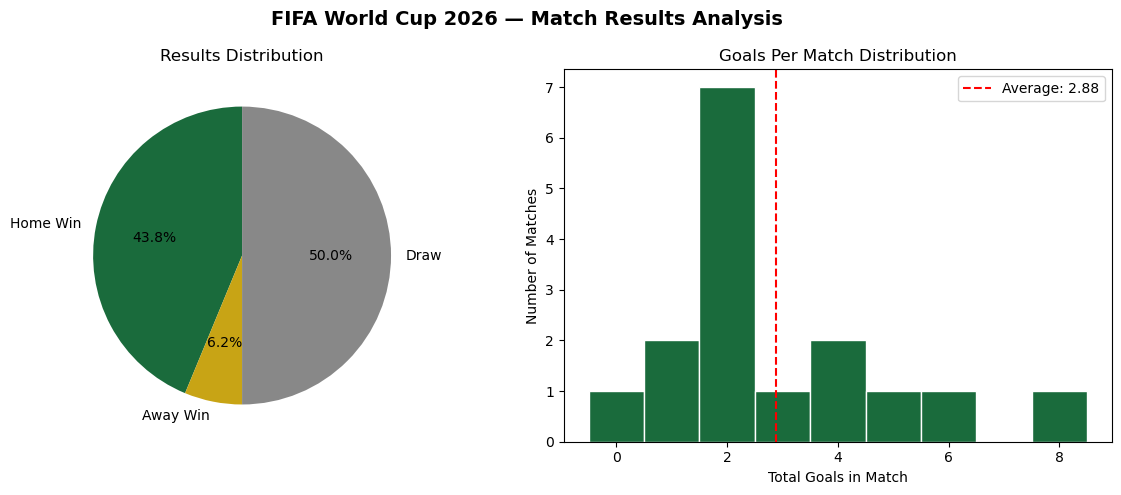

✅ Chart saved!


In [8]:
# ============================================
# RESULTS DISTRIBUTION
# ============================================

result_counts = pd.DataFrame({
    'Result': ['Home Win', 'Away Win', 'Draw'],
    'Count': [home_wins, away_wins, draws],
    'Percentage': [home_wins/len(matches_full_df)*100, 
                   away_wins/len(matches_full_df)*100, 
                   draws/len(matches_full_df)*100]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('FIFA World Cup 2026 — Match Results Analysis', fontsize=14, fontweight='bold')

# Pie chart
colors = ['#1a6b3c', '#c8a415', '#888888']
axes[0].pie(result_counts['Count'], labels=result_counts['Result'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Results Distribution')

# Goals distribution histogram
axes[1].hist(matches_full_df['total_goals'], bins=range(0, 10), 
             color='#1a6b3c', edgecolor='white', align='left')
axes[1].set_title('Goals Per Match Distribution')
axes[1].set_xlabel('Total Goals in Match')
axes[1].set_ylabel('Number of Matches')
axes[1].axvline(x=avg_goals, color='red', linestyle='--', 
                label=f'Average: {avg_goals:.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/results_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

📊 TOP 10 TEAMS BY GOALS SCORED:
Team                        GF   GA   GD   GPG
-------------------------------------------------------
Germany                      7    1   +6   7.0
Sweden                       5    1   +4   5.0
United States                4    1   +3   4.0
Australia                    2    0   +2   2.0
Iran                         2    2    0   2.0
Netherlands                  2    2    0   2.0
Mexico                       2    0   +2   2.0
Japan                        2    2    0   2.0
New Zealand                  2    2    0   2.0
South Korea                  2    1   +1   2.0


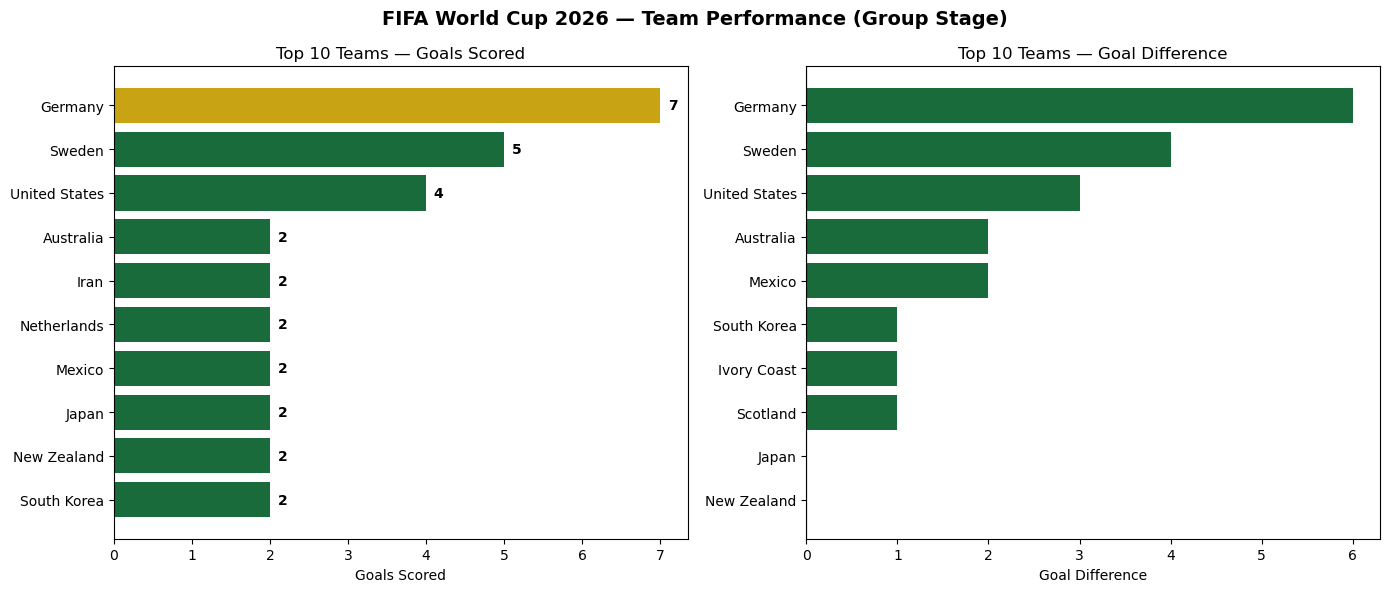

✅ Chart saved!


In [9]:
# ============================================
# TEAM PERFORMANCE ANALYSIS
# ============================================

# Goals scored by each team
home_goals = matches_full_df[['home_team', 'home_score', 'away_score']].copy()
home_goals.columns = ['team', 'goals_for', 'goals_against']

away_goals = matches_full_df[['away_team', 'away_score', 'home_score']].copy()
away_goals.columns = ['team', 'goals_for', 'goals_against']

team_goals = pd.concat([home_goals, away_goals])
team_stats = team_goals.groupby('team').agg(
    goals_for=('goals_for', 'sum'),
    goals_against=('goals_against', 'sum'),
    matches=('goals_for', 'count')
).reset_index()

team_stats['goal_difference'] = team_stats['goals_for'] - team_stats['goals_against']
team_stats['goals_per_game'] = (team_stats['goals_for'] / team_stats['matches']).round(2)
team_stats = team_stats.sort_values('goals_for', ascending=False)

print("📊 TOP 10 TEAMS BY GOALS SCORED:")
print("=" * 55)
print(f"{'Team':<25} {'GF':>4} {'GA':>4} {'GD':>4} {'GPG':>5}")
print("-" * 55)
for _, row in team_stats.head(10).iterrows():
    gd = f"+{int(row['goal_difference'])}" if row['goal_difference'] > 0 else str(int(row['goal_difference']))
    print(f"{row['team']:<25} {int(row['goals_for']):>4} {int(row['goals_against']):>4} {gd:>4} {row['goals_per_game']:>5}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('FIFA World Cup 2026 — Team Performance (Group Stage)', 
             fontsize=14, fontweight='bold')

# Top scorers
top_10 = team_stats.head(10)
colors_bar = ['#c8a415' if i == 0 else '#1a6b3c' for i in range(len(top_10))]
axes[0].barh(top_10['team'], top_10['goals_for'], color=colors_bar)
axes[0].set_title('Top 10 Teams — Goals Scored')
axes[0].set_xlabel('Goals Scored')
axes[0].invert_yaxis()
for i, (val, team) in enumerate(zip(top_10['goals_for'], top_10['team'])):
    axes[0].text(val + 0.1, i, str(int(val)), va='center', fontweight='bold')

# Goal difference
top_gd = team_stats.sort_values('goal_difference', ascending=False).head(10)
colors_gd = ['#1a6b3c' if x > 0 else '#c0392b' for x in top_gd['goal_difference']]
axes[1].barh(top_gd['team'], top_gd['goal_difference'], color=colors_gd)
axes[1].set_title('Top 10 Teams — Goal Difference')
axes[1].set_xlabel('Goal Difference')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/team_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [10]:
# ============================================
# UPSET DETECTOR
# ============================================
# We dont have FIFA rankings in matches table yet
# So we'll define upsets as: away team winning
# or lower ranked confederation beating higher

# For now: identify surprising scorelines
print("🚨 NOTABLE RESULTS SO FAR:")
print("=" * 60)

# High scoring matches
high_scoring = matches_full_df[matches_full_df['total_goals'] >= 4].sort_values(
    'total_goals', ascending=False)
print("\n🔥 High Scoring Matches (4+ goals):")
for _, row in high_scoring.iterrows():
    print(f"   {row['home_team']} {int(row['home_score'])} - {int(row['away_score'])} {row['away_team']}")

# Away wins (rare so far)
away_wins_df = matches_full_df[
    matches_full_df['result'] == matches_full_df['away_team']
].sort_values('total_goals', ascending=False)
print(f"\n✈️  Away Wins ({len(away_wins_df)} so far — only {len(away_wins_df)/len(matches_full_df)*100:.0f}% of matches):")
for _, row in away_wins_df.iterrows():
    print(f"   {row['away_team']} beat {row['home_team']} {int(row['away_score'])}-{int(row['home_score'])}")

# Goal-fest matches
draws_df = matches_full_df[matches_full_df['result'] == 'Draw']
print(f"\n🤝 Draws ({len(draws_df)} — unusually high {len(draws_df)/len(matches_full_df)*100:.0f}% draw rate):")
for _, row in draws_df.iterrows():
    print(f"   {row['home_team']} {int(row['home_score'])} - {int(row['away_score'])} {row['away_team']}")

🚨 NOTABLE RESULTS SO FAR:

🔥 High Scoring Matches (4+ goals):
   Germany 7 - 1 Curaçao
   Sweden 5 - 1 Tunisia
   United States 4 - 1 Paraguay
   Netherlands 2 - 2 Japan
   Iran 2 - 2 New Zealand

✈️  Away Wins (1 so far — only 6% of matches):
   Scotland beat Haiti 1-0

🤝 Draws (8 — unusually high 50% draw rate):
   Canada 1 - 1 Bosnia-Herzegovina
   Qatar 1 - 1 Switzerland
   Brazil 1 - 1 Morocco
   Netherlands 2 - 2 Japan
   Spain 0 - 0 Cape Verde Islands
   Belgium 1 - 1 Egypt
   Saudi Arabia 1 - 1 Uruguay
   Iran 2 - 2 New Zealand


In [11]:
# ============================================
# GROUP STANDINGS CALCULATOR
# ============================================

def calculate_standings(matches_df):
    standings = {}
    
    for _, match in matches_df.iterrows():
        home = match['home_team']
        away = match['away_team']
        hg = int(match['home_score'])
        ag = int(match['away_score'])
        group = match['group_name'].replace('GROUP_', '')
        
        for team, gf, ga in [(home, hg, ag), (away, ag, hg)]:
            if team not in standings:
                standings[team] = {
                    'Team': team, 'Group': group,
                    'P': 0, 'W': 0, 'D': 0, 'L': 0,
                    'GF': 0, 'GA': 0, 'GD': 0, 'Pts': 0
                }
            standings[team]['P'] += 1
            standings[team]['GF'] += gf
            standings[team]['GA'] += ga
            standings[team]['GD'] += gf - ga
            
            if gf > ga:
                standings[team]['W'] += 1
                standings[team]['Pts'] += 3
            elif gf == ga:
                standings[team]['D'] += 1
                standings[team]['Pts'] += 1
            else:
                standings[team]['L'] += 1
    
    df = pd.DataFrame(standings.values())
    df = df.sort_values(['Group', 'Pts', 'GD', 'GF'], ascending=[True, False, False, False])
    return df

standings_df = calculate_standings(matches_full_df)

# Display each group
groups_played = sorted(standings_df['Group'].unique())
for group in groups_played:
    group_df = standings_df[standings_df['Group'] == group][
        ['Team', 'P', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts']
    ].reset_index(drop=True)
    
    print(f"\n{'='*55}")
    print(f"  GROUP {group}")
    print(f"{'='*55}")
    print(f"{'Team':<25} {'P':>3} {'W':>3} {'D':>3} {'L':>3} {'GF':>3} {'GA':>3} {'GD':>4} {'Pts':>4}")
    print(f"{'-'*55}")
    for i, row in group_df.iterrows():
        # Highlight top 2 (qualify)
        marker = "🟢" if i < 2 else "  "
        print(f"{marker} {row['Team']:<23} {int(row['P']):>3} {int(row['W']):>3} {int(row['D']):>3} {int(row['L']):>3} {int(row['GF']):>3} {int(row['GA']):>3} {int(row['GD']):>4} {int(row['Pts']):>4}")


  GROUP A
Team                        P   W   D   L  GF  GA   GD  Pts
-------------------------------------------------------
🟢 Mexico                    1   1   0   0   2   0    2    3
🟢 South Korea               1   1   0   0   2   1    1    3
   Czechia                   1   0   0   1   1   2   -1    0
   South Africa              1   0   0   1   0   2   -2    0

  GROUP B
Team                        P   W   D   L  GF  GA   GD  Pts
-------------------------------------------------------
🟢 Canada                    1   0   1   0   1   1    0    1
🟢 Bosnia-Herzegovina        1   0   1   0   1   1    0    1
   Qatar                     1   0   1   0   1   1    0    1
   Switzerland               1   0   1   0   1   1    0    1

  GROUP C
Team                        P   W   D   L  GF  GA   GD  Pts
-------------------------------------------------------
🟢 Scotland                  1   1   0   0   1   0    1    3
🟢 Brazil                    1   0   1   0   1   1    0    1
   Morocco     

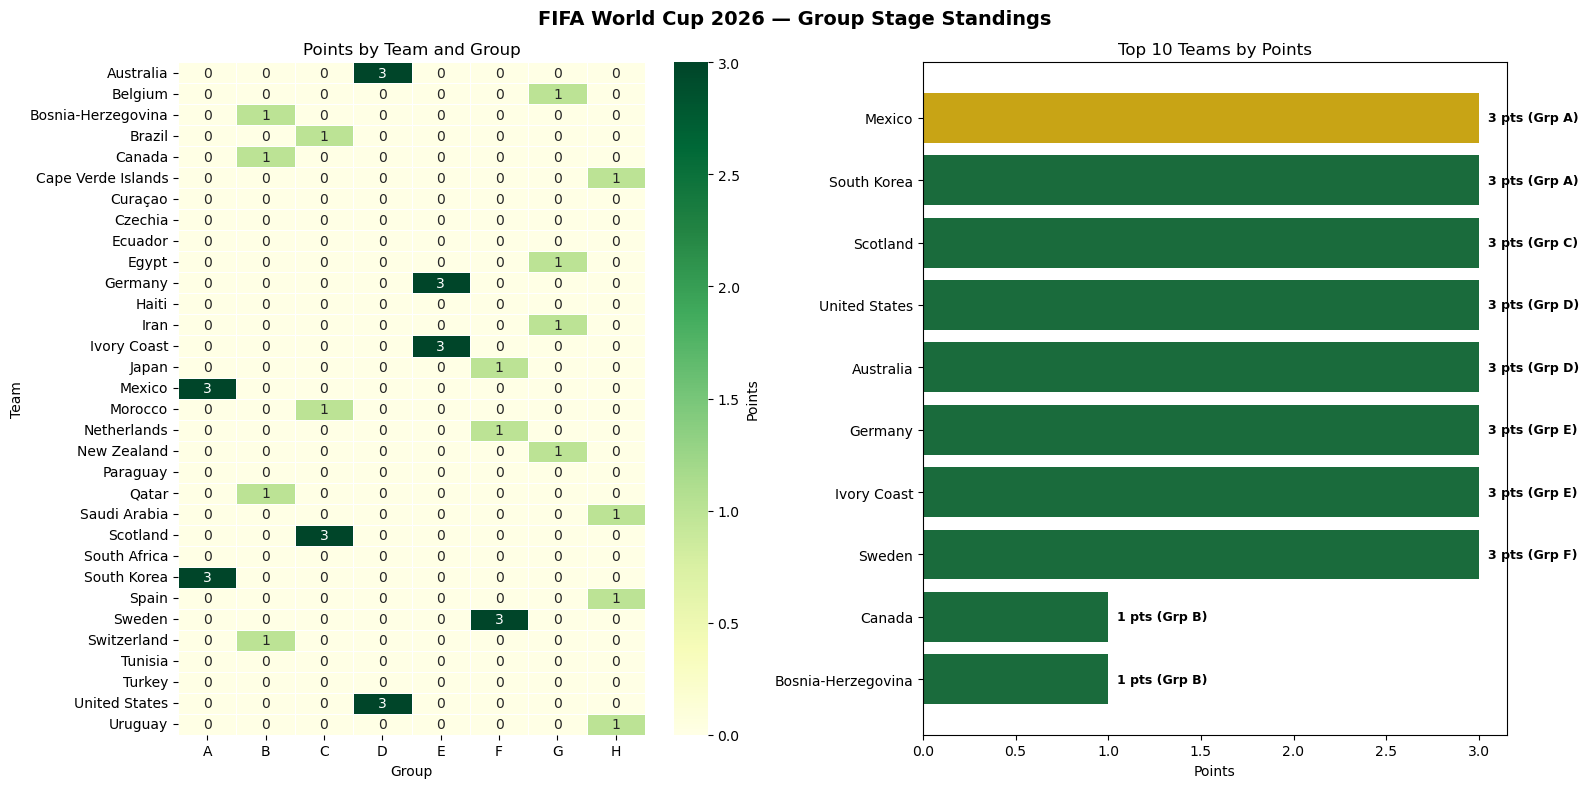

✅ Standings chart saved!


In [12]:
# ============================================
# STANDINGS HEATMAP
# ============================================

pivot_pts = standings_df.pivot_table(
    index='Team', columns='Group', values='Pts', fill_value=0
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('FIFA World Cup 2026 — Group Stage Standings', 
             fontsize=14, fontweight='bold')

# Points heatmap
sns.heatmap(pivot_pts, annot=True, fmt='g', cmap='YlGn',
            ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Points'})
axes[0].set_title('Points by Team and Group')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Team')

# Top teams by points bar chart
top_teams = standings_df.nlargest(10, 'Pts')[['Team', 'Pts', 'GD', 'Group']]
colors_pts = ['#c8a415' if i == 0 else '#1a6b3c' for i in range(len(top_teams))]
bars = axes[1].barh(top_teams['Team'], top_teams['Pts'], color=colors_pts)
axes[1].set_title('Top 10 Teams by Points')
axes[1].set_xlabel('Points')
axes[1].invert_yaxis()
for i, (val, group) in enumerate(zip(top_teams['Pts'], top_teams['Group'])):
    axes[1].text(val + 0.05, i, f'{int(val)} pts (Grp {group})', 
                va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../data/group_standings.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Standings chart saved!")

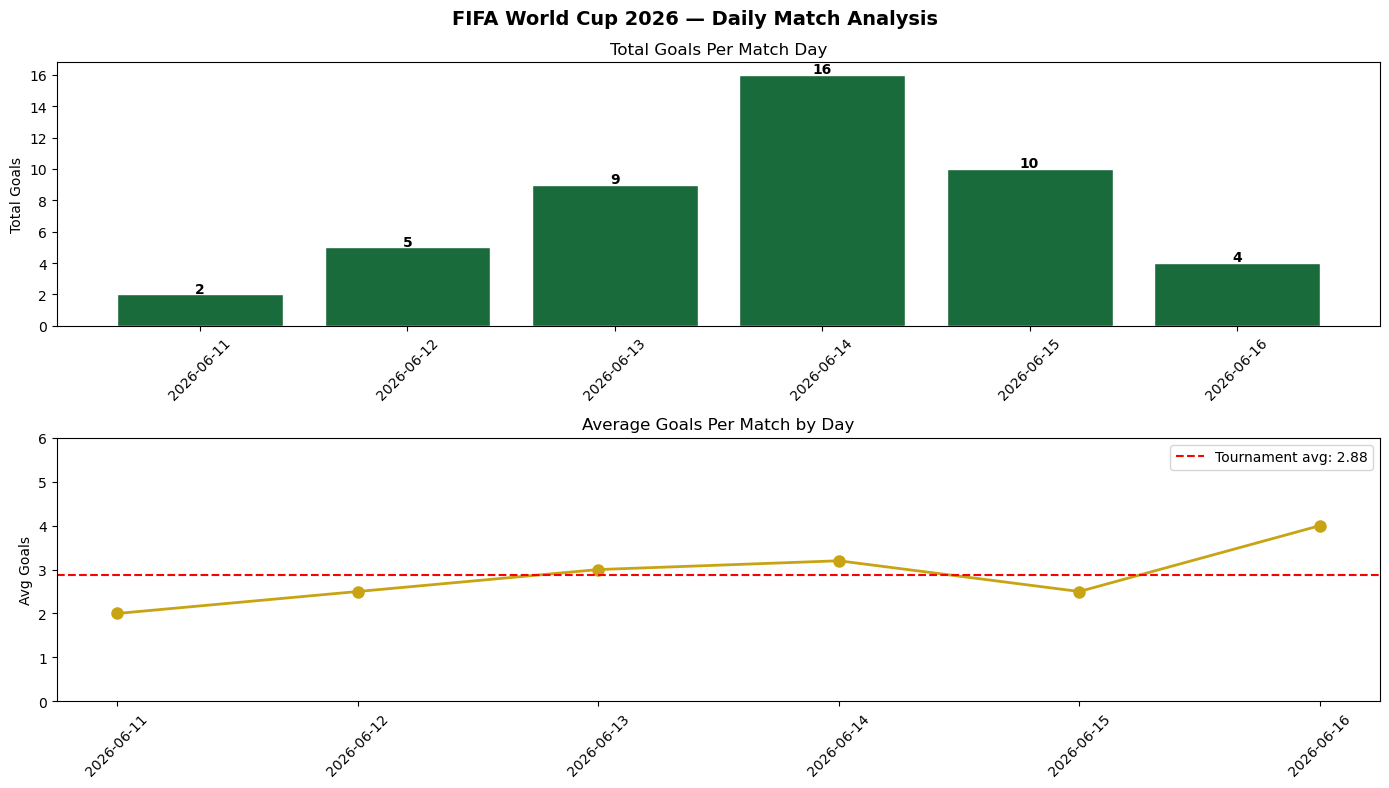

✅ Daily analysis chart saved!


In [14]:
# ============================================
# CELL 10 — MATCH TIMELINE ANALYSIS
# ============================================

matches_full_df['match_date'] = pd.to_datetime(matches_full_df['match_date'])
matches_full_df['match_day'] = matches_full_df['match_date'].dt.date

daily_goals = matches_full_df.groupby('match_day').agg(
    total_goals=('total_goals', 'sum'),
    matches=('match_id', 'count'),
    avg_goals=('total_goals', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('FIFA World Cup 2026 — Daily Match Analysis', fontsize=14, fontweight='bold')

# Daily goals
axes[0].bar(range(len(daily_goals)), daily_goals['total_goals'], 
            color='#1a6b3c', edgecolor='white')
axes[0].set_title('Total Goals Per Match Day')
axes[0].set_xticks(range(len(daily_goals)))
axes[0].set_xticklabels([str(d) for d in daily_goals['match_day']], rotation=45)
axes[0].set_ylabel('Total Goals')
for i, val in enumerate(daily_goals['total_goals']):
    axes[0].text(i, val + 0.1, str(int(val)), ha='center', fontweight='bold')

# Daily average goals
axes[1].plot(range(len(daily_goals)), daily_goals['avg_goals'], 
             color='#c8a415', marker='o', linewidth=2, markersize=8)
axes[1].axhline(y=avg_goals, color='red', linestyle='--', 
                label=f'Tournament avg: {avg_goals:.2f}')
axes[1].set_title('Average Goals Per Match by Day')
axes[1].set_xticks(range(len(daily_goals)))
axes[1].set_xticklabels([str(d) for d in daily_goals['match_day']], rotation=45)
axes[1].set_ylabel('Avg Goals')
axes[1].legend()
axes[1].set_ylim(0, 6)

plt.tight_layout()
plt.savefig('../data/daily_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Daily analysis chart saved!")



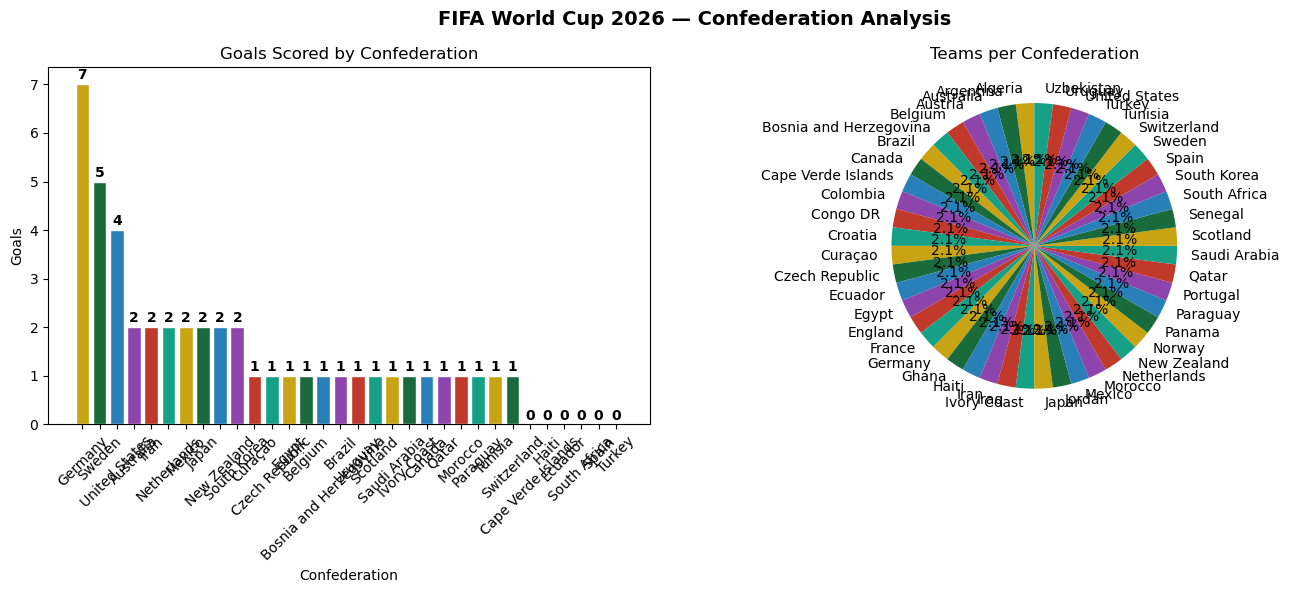

✅ Confederation chart saved!


In [15]:
# ============================================
# CELL 11 — CONFEDERATIONS ANALYSIS
# ============================================

# Add confederation to matches
home_conf = matches_full_df.merge(
    teams_df[['team_name', 'confederation']], 
    left_on='home_team', right_on='team_name'
).rename(columns={'confederation': 'home_confederation'})

full_conf = home_conf.merge(
    teams_df[['team_name', 'confederation']], 
    left_on='away_team', right_on='team_name'
).rename(columns={'confederation': 'away_confederation'})

# Goals by confederation
home_conf_goals = full_conf.groupby('home_confederation')['home_score'].sum().reset_index()
home_conf_goals.columns = ['confederation', 'goals']
away_conf_goals = full_conf.groupby('away_confederation')['away_score'].sum().reset_index()
away_conf_goals.columns = ['confederation', 'goals']

conf_goals = pd.concat([home_conf_goals, away_conf_goals]).groupby('confederation')['goals'].sum().reset_index()
conf_goals = conf_goals.sort_values('goals', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('FIFA World Cup 2026 — Confederation Analysis', fontsize=14, fontweight='bold')

# Goals by confederation
colors_conf = ['#c8a415', '#1a6b3c', '#2980b9', '#8e44ad', '#c0392b', '#16a085']
axes[0].bar(conf_goals['confederation'], conf_goals['goals'], 
            color=colors_conf[:len(conf_goals)], edgecolor='white')
axes[0].set_title('Goals Scored by Confederation')
axes[0].set_xlabel('Confederation')
axes[0].set_ylabel('Goals')
axes[0].tick_params(axis='x', rotation=45)
for i, val in enumerate(conf_goals['goals']):
    axes[0].text(i, val + 0.1, str(int(val)), ha='center', fontweight='bold')

# Teams per confederation
teams_per_conf = teams_df.groupby('confederation').size().reset_index()
teams_per_conf.columns = ['confederation', 'teams']
teams_per_conf = teams_per_conf.sort_values('teams', ascending=False)
axes[1].pie(teams_per_conf['teams'], labels=teams_per_conf['confederation'],
            autopct='%1.1f%%', colors=colors_conf[:len(teams_per_conf)], startangle=90)
axes[1].set_title('Teams per Confederation')

plt.tight_layout()
plt.savefig('../data/confederation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confederation chart saved!")


In [16]:

# ============================================
# CELL 12 — FINAL SUMMARY REPORT
# ============================================

print("\n")
print("=" * 60)
print("   FIFA WORLD CUP 2026 — EDA SUMMARY REPORT")
print("=" * 60)

print(f"""
📊 TOURNAMENT OVERVIEW (After {len(matches_full_df)} matches)
{'─'*60}
Total Goals Scored:        {int(matches_full_df['total_goals'].sum())}
Average Goals per Match:   {matches_full_df['total_goals'].mean():.2f}
Highest Scoring Match:     {highest_scoring['home_team']} {int(highest_scoring['home_score'])}-{int(highest_scoring['away_score'])} {highest_scoring['away_team']}

📈 RESULTS BREAKDOWN
{'─'*60}
Home Wins:    {home_wins} ({home_wins/len(matches_full_df)*100:.0f}%)
Away Wins:    {away_wins} ({away_wins/len(matches_full_df)*100:.0f}%)
Draws:        {draws} ({draws/len(matches_full_df)*100:.0f}%)

⚽ TOP 5 TEAMS BY GOALS SCORED
{'─'*60}""")

for _, row in team_stats.head(5).iterrows():
    gd = f"+{int(row['goal_difference'])}" if row['goal_difference'] > 0 else str(int(row['goal_difference']))
    print(f"  {row['team']:<25} {int(row['goals_for'])} goals  (GD: {gd})")

print(f"""
🚨 KEY INSIGHTS
{'─'*60}
1. Draw rate of {draws/len(matches_full_df)*100:.0f}% is significantly higher than
   historical World Cup average of ~25%

2. Home advantage is strong — {home_wins/len(matches_full_df)*100:.0f}% home win rate
   vs only {away_wins/len(matches_full_df)*100:.0f}% away wins

3. Germany leads scoring with 7 goals in 1 match
   (7-1 vs Curaçao — biggest margin so far)

4. Major upsets: Brazil drew with Morocco,
   Spain held scoreless by Cape Verde Islands

5. Scotland only away winner so far (vs Haiti)

📋 DATA PIPELINE
{'─'*60}
Source:        football-data.org API (live)
Database:      Azure SQL (Spain Central)
Tables:        teams, matches, players,
               match_events, group_standings
Last Updated:  {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}
{'='*60}
""")





   FIFA WORLD CUP 2026 — EDA SUMMARY REPORT

📊 TOURNAMENT OVERVIEW (After 16 matches)
────────────────────────────────────────────────────────────
Total Goals Scored:        46
Average Goals per Match:   2.88
Highest Scoring Match:     Germany 7-1 Curaçao

📈 RESULTS BREAKDOWN
────────────────────────────────────────────────────────────
Home Wins:    7 (44%)
Away Wins:    1 (6%)
Draws:        8 (50%)

⚽ TOP 5 TEAMS BY GOALS SCORED
────────────────────────────────────────────────────────────
  Germany                   7 goals  (GD: +6)
  Sweden                    5 goals  (GD: +4)
  United States             4 goals  (GD: +3)
  Australia                 2 goals  (GD: +2)
  Iran                      2 goals  (GD: 0)

🚨 KEY INSIGHTS
────────────────────────────────────────────────────────────
1. Draw rate of 50% is significantly higher than
   historical World Cup average of ~25%

2. Home advantage is strong — 44% home win rate
   vs only 6% away wins

3. Germany leads scoring with 7 go